## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [3]:
#For clean visualizations

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## Loading datasets

In [4]:
forwards = pd.read_csv("../data/forwards.csv", encoding="latin1")
midfielders = pd.read_csv("../data/midfielders.csv", encoding="latin1")
defenders = pd.read_csv("../data/defenders.csv", encoding="latin1")
goalkeepers = pd.read_csv("../data/goalkeepers.csv", encoding="latin1")

#### Checking first few rows of each data sets

In [5]:
forwards.head()

,player,position,team,age,club,birth_year,games,games_starts,minutes,minutes_90s,...,xg,npxg,xg_assist,npxg_xg_assist,xg_per90,xg_assist_per90,xg_xg_assist_per90,npxg_per90,npxg_xg_assist_per90,general_position
0,Abderrazak Hamdallah,FW,Morocco,32-001,Al-Ittihad,1990,4,0,68,0.8,...,0.4,0.4,0.0,0.4,0.52,0.00,0.52,0.52,0.52,Forward
1,Abdessamad Ezzalzouli,FW,Morocco,21-001,Osasuna,2001,3,0,93,1.0,...,0.1,0.1,0.3,0.3,0.09,0.39,0.49,0.09,0.49,Forward
2,Abdul Fatawu Issahaku,FW,Ghana,18-285,Sporting CP,2004,1,0,1,0.0,...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,Forward
3,Ahmed Alaaeldin,FW,Qatar,29-321,Al-Gharafa Sports Club,1993,1,0,6,0.1,...,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,Forward
4,Akram Afif,FW,Qatar,26-030,Al Sadd SC,1996,3,3,270,3.0,...,0.0,0.0,0.3,0.3,0.02,0.10,0.12,0.02,0.12,Forward


In [6]:
midfielders.head()

,player,position,team,age,club,birth_year,games,games_starts,minutes,minutes_90s,...,xg_assist_per90,xg_xg_assist_per90,npxg_per90,npxg_xg_assist_per90,general_position,big_chance,chance_created_per90,pass_per90,tackles_per90,successful_dribbles
0,Aaron Mooy,MF,Australia,35,Celtic,1990,4,4,360,4.0,...,0.02,0.03,0.01,0.03,Midfielder,0,0.0,0.0,0.0,0.0
1,Aaron Ramsey,MF,Wales,35,Nice,1990,3,3,266,3.0,...,0.01,0.02,0.01,0.02,Midfielder,0,0.0,0.0,0.0,0.0
2,Abdelhamid Sabiri,MF,Morocco,29,Sampdoria,1996,5,2,181,2.0,...,0.53,0.60,0.08,0.60,Midfielder,0,0.0,0.0,0.0,0.0
3,Abdulaziz Hatem,MF,Qatar,35,Al Rayyan SC,1990,3,2,196,2.2,...,0.01,0.02,0.01,0.02,Midfielder,0,0.0,0.0,0.0,0.0
4,Abdulellah Al-Malki,MF,Saudi Arabia,31,Al-Hilal,1994,2,2,174,1.9,...,0.00,0.06,0.06,0.06,Midfielder,0,0.0,0.0,0.0,0.0


In [7]:
defenders.head()

,player,position,team,age,club,birth_year,games,games_starts,minutes,minutes_90s,...,xg_per90,xg_assist_per90,xg_xg_assist_per90,npxg_per90,npxg_xg_assist_per90,general_position,pass_success,clearance_per90,chance_created_per90,success_tackles_per90
0,Abdelkarim Hassan,DF,Qatar,29-112,Al Sadd SC,1993,3,3,270,3.0,...,0.10,0.01,0.11,0.10,0.11,Defender,0.0,0.0,0.0,0.0
1,Abdou Diallo,DF,Senegal,26-228,RB Leipzig,1996,4,4,331,3.7,...,0.01,0.02,0.03,0.01,0.03,Defender,0.0,0.0,0.0,0.0
2,Abdulelah Al-Amri,DF,Saudi Arabia,25-337,Al-Nassr,1997,3,2,182,2.0,...,0.03,0.00,0.03,0.03,0.03,Defender,0.0,0.0,0.0,0.0
3,Abdullah Madu,DF,Saudi Arabia,29-156,Al-Nassr,1993,1,0,45,0.5,...,0.00,0.00,0.00,0.00,0.00,Defender,0.0,0.0,0.0,0.0
4,Abolfazl Jalali,DF,IR Iran,24-175,Esteghlal,1998,1,0,19,0.2,...,0.00,0.00,0.00,0.00,0.00,Defender,0.0,0.0,0.0,0.0


In [8]:
goalkeepers.head()

,player,position,team,age,club,birth_year,games,games_starts,minutes,minutes_90s,...,xg_assist_per90,xg_xg_assist_per90,npxg_per90,npxg_xg_assist_per90,Clean_s,saves,general_position,goal_conceded,goals_conceded_per90,save_percentage
0,Aymen Dahmen,GK,Tunisia,28,CS Sfaxien,1997,3,3,270,3.0,...,0.0,0.0,0,0.0,2,9,Goalkeeper,1,0.333333,90.000000
1,Alireza Beiranvand,GK,IR Iran,33,Persepolis,1992,2,2,109,1.2,...,0.0,0.0,0,0.0,0,5,Goalkeeper,7,5.779817,41.666667
2,Alisson,GK,Brazil,33,Liverpool,1992,4,4,379,4.2,...,0.0,0.0,0,0.0,2,5,Goalkeeper,2,0.474934,71.428571
3,Andries Noppert,GK,Netherlands,31,Heerenveen,1994,5,5,480,5.3,...,0.0,0.0,0,0.0,2,18,Goalkeeper,4,0.750000,81.818182
4,Andre Onana,GK,Cameroon,29,Inter,1996,1,1,80,0.9,...,0.0,0.0,0,0.0,0,2,Goalkeeper,1,1.125000,66.666667


## Checking Dataset Shape

In [9]:
print("Forwards:", forwards.shape)
print("Midfielders:", midfielders.shape)
print("Defenders:", defenders.shape)
print("Goalkeepers:", goalkeepers.shape)

Forwards: (185, 32)
Midfielders: (226, 37)
Defenders: (228, 36)
Goalkeepers: (41, 32)


## Inspecting columns to check available metrics

In [10]:
forwards.columns

Index(['player', 'position', 'team', 'age', 'club', 'birth_year', 'games',
       'games_starts', 'minutes', 'minutes_90s', 'goals', 'assists',
       'goals_pens', 'pens_made', 'pens_att', 'cards_yellow', 'cards_red',
       'goals_per90', 'assists_per90', 'goals_assists_per90',
       'goals_pens_per90', 'goals_assists_pens_per90', 'xg', 'npxg',
       'xg_assist', 'npxg_xg_assist', 'xg_per90', 'xg_assist_per90',
       'xg_xg_assist_per90', 'npxg_per90', 'npxg_xg_assist_per90',
       'general_position'],
      dtype='object')

In [11]:
midfielders.columns

Index(['player', 'position', 'team', 'age', 'club', 'birth_year', 'games',
       'games_starts', 'minutes', 'minutes_90s', 'goals', 'assists',
       'goals_pens', 'pens_made', 'pens_att', 'cards_yellow', 'cards_red',
       'goals_per90', 'assists_per90', 'goals_assists_per90',
       'goals_pens_per90', 'goals_assists_pens_per90', 'xg', 'npxg',
       'xg_assist', 'npxg_xg_assist', 'xg_per90', 'xg_assist_per90',
       'xg_xg_assist_per90', 'npxg_per90', 'npxg_xg_assist_per90',
       'general_position', 'big_chance', 'chance_created_per90', 'pass_per90',
       'tackles_per90', 'successful_dribbles'],
      dtype='object')

In [12]:
defenders.columns

Index(['player', 'position', 'team', 'age', 'club', 'birth_year', 'games',
       'games_starts', 'minutes', 'minutes_90s', 'goals', 'assists',
       'goals_pens', 'pens_made', 'pens_att', 'cards_yellow', 'cards_red',
       'goals_per90', 'assists_per90', 'goals_assists_per90',
       'goals_pens_per90', 'goals_assists_pens_per90', 'xg', 'npxg',
       'xg_assist', 'npxg_xg_assist', 'xg_per90', 'xg_assist_per90',
       'xg_xg_assist_per90', 'npxg_per90', 'npxg_xg_assist_per90',
       'general_position', 'pass_success', 'clearance_per90',
       'chance_created_per90', 'success_tackles_per90'],
      dtype='object')

In [13]:
goalkeepers.columns

Index(['player', 'position', 'team', 'age', 'club', 'birth_year', 'games',
       'games_starts', 'minutes', 'minutes_90s', 'goals', 'assists',
       'pens_sav', 'cards_yellow', 'cards_red', 'goals_per90', 'assists_per90',
       'xg', 'npxg', 'xg_assist', 'npxg_xg_assist', 'xg_per90',
       'xg_assist_per90', 'xg_xg_assist_per90', 'npxg_per90',
       'npxg_xg_assist_per90', 'Clean_s', 'saves', 'general_position',
       'goal_conceded', 'goals_conceded_per90', 'save_percentage'],
      dtype='object')

#### Checking datatypes

In [14]:
forwards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player                    185 non-null    object 
 1   position                  185 non-null    object 
 2   team                      185 non-null    object 
 3   age                       185 non-null    object 
 4   club                      184 non-null    object 
 5   birth_year                185 non-null    int64  
 6   games                     185 non-null    int64  
 7   games_starts              185 non-null    int64  
 8   minutes                   185 non-null    int64  
 9   minutes_90s               185 non-null    float64
 10  goals                     185 non-null    int64  
 11  assists                   185 non-null    int64  
 12  goals_pens                185 non-null    int64  
 13  pens_made                 185 non-null    int64  
 14  pens_att  

In [15]:
midfielders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player                    226 non-null    object 
 1   position                  226 non-null    object 
 2   team                      226 non-null    object 
 3   age                       226 non-null    int64  
 4   club                      226 non-null    object 
 5   birth_year                226 non-null    int64  
 6   games                     226 non-null    int64  
 7   games_starts              226 non-null    int64  
 8   minutes                   226 non-null    int64  
 9   minutes_90s               226 non-null    float64
 10  goals                     226 non-null    int64  
 11  assists                   226 non-null    int64  
 12  goals_pens                226 non-null    int64  
 13  pens_made                 226 non-null    int64  
 14  pens_att  

In [16]:
defenders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player                    228 non-null    object 
 1   position                  228 non-null    object 
 2   team                      228 non-null    object 
 3   age                       228 non-null    object 
 4   club                      228 non-null    object 
 5   birth_year                228 non-null    int64  
 6   games                     228 non-null    int64  
 7   games_starts              228 non-null    int64  
 8   minutes                   228 non-null    int64  
 9   minutes_90s               228 non-null    float64
 10  goals                     228 non-null    int64  
 11  assists                   228 non-null    int64  
 12  goals_pens                228 non-null    int64  
 13  pens_made                 228 non-null    int64  
 14  pens_att  

In [17]:
goalkeepers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   player                41 non-null     object 
 1   position              41 non-null     object 
 2   team                  41 non-null     object 
 3   age                   41 non-null     int64  
 4   club                  41 non-null     object 
 5   birth_year            41 non-null     int64  
 6   games                 41 non-null     int64  
 7   games_starts          41 non-null     int64  
 8   minutes               41 non-null     int64  
 9   minutes_90s           41 non-null     float64
 10  goals                 41 non-null     int64  
 11  assists               41 non-null     int64  
 12  pens_sav              41 non-null     int64  
 13  cards_yellow          41 non-null     int64  
 14  cards_red             41 non-null     int64  
 15  goals_per90           41 

#### Checking Missing Values

In [18]:
forwards.isnull().sum()

player                      0
position                    0
team                        0
age                         0
club                        1
birth_year                  0
games                       0
games_starts                0
minutes                     0
minutes_90s                 0
goals                       0
assists                     0
goals_pens                  0
pens_made                   0
pens_att                    0
cards_yellow                0
cards_red                   0
goals_per90                 0
assists_per90               0
goals_assists_per90         0
goals_pens_per90            0
goals_assists_pens_per90    0
xg                          1
npxg                        1
xg_assist                   1
npxg_xg_assist              1
xg_per90                    2
xg_assist_per90             2
xg_xg_assist_per90          2
npxg_per90                  2
npxg_xg_assist_per90        2
general_position            0
dtype: int64

In [19]:
midfielders.isnull().sum()

player                      0
position                    0
team                        0
age                         0
club                        0
birth_year                  0
games                       0
games_starts                0
minutes                     0
minutes_90s                 0
goals                       0
assists                     0
goals_pens                  0
pens_made                   0
pens_att                    0
cards_yellow                0
cards_red                   0
goals_per90                 0
assists_per90               0
goals_assists_per90         0
goals_pens_per90            0
goals_assists_pens_per90    0
xg                          1
npxg                        1
xg_assist                   1
npxg_xg_assist              1
xg_per90                    1
xg_assist_per90             1
xg_xg_assist_per90          1
npxg_per90                  1
npxg_xg_assist_per90        1
general_position            0
big_chance                  0
chance_cre

In [20]:
defenders.isnull().sum()

player                      0
position                    0
team                        0
age                         0
club                        0
birth_year                  0
games                       0
games_starts                0
minutes                     0
minutes_90s                 0
goals                       0
assists                     0
goals_pens                  0
pens_made                   0
pens_att                    0
cards_yellow                0
cards_red                   0
goals_per90                 0
assists_per90               0
goals_assists_per90         0
goals_pens_per90            0
goals_assists_pens_per90    0
xg                          0
npxg                        0
xg_assist                   0
npxg_xg_assist              0
xg_per90                    0
xg_assist_per90             0
xg_xg_assist_per90          0
npxg_per90                  0
npxg_xg_assist_per90        0
general_position            0
pass_success                0
clearance_

In [21]:
goalkeepers.isnull().sum()

player                  0
position                0
team                    0
age                     0
club                    0
birth_year              0
games                   0
games_starts            0
minutes                 0
minutes_90s             0
goals                   0
assists                 0
pens_sav                0
cards_yellow            0
cards_red               0
goals_per90             0
assists_per90           0
xg                      0
npxg                    0
xg_assist               0
npxg_xg_assist          0
xg_per90                0
xg_assist_per90         0
xg_xg_assist_per90      0
npxg_per90              0
npxg_xg_assist_per90    0
Clean_s                 0
saves                   0
general_position        0
goal_conceded           0
goals_conceded_per90    0
save_percentage         0
dtype: int64

#### Basic Statistics 

In [22]:
forwards.describe()

,birth_year,games,games_starts,minutes,minutes_90s,goals,assists,goals_pens,pens_made,pens_att,...,goals_assists_pens_per90,xg,npxg,xg_assist,npxg_xg_assist,xg_per90,xg_assist_per90,xg_xg_assist_per90,npxg_per90,npxg_xg_assist_per90
count,185.00000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,...,185.000000,184.000000,184.000000,184.000000,184.000000,183.000000,183.000000,183.000000,183.000000,183.000000
mean,1995.52973,3.081081,1.756757,163.075676,1.810811,0.616216,0.259459,0.540541,0.075676,0.091892,...,0.352865,0.564674,0.490217,0.246739,0.739674,0.309454,0.135519,0.444645,0.291311,0.426393
std,4.04599,1.573876,1.805869,137.651753,1.531727,1.141489,0.614790,0.955379,0.382643,0.474558,...,0.591899,0.852000,0.633329,0.394761,0.856222,0.434546,0.240212,0.492937,0.427809,0.485562
min,1985.00000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1992.00000,2.000000,0.000000,58.000000,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.100000,0.040000,0.000000,0.150000,0.030000,0.145000
50%,1996.00000,3.000000,1.000000,135.000000,1.500000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.300000,0.300000,0.100000,0.500000,0.190000,0.060000,0.310000,0.180000,0.310000
75%,1999.00000,4.000000,3.000000,241.000000,2.700000,1.000000,0.000000,1.000000,0.000000,0.000000,...,0.620000,0.800000,0.725000,0.300000,1.100000,0.415000,0.165000,0.570000,0.365000,0.560000
max,2004.00000,7.000000,7.000000,690.000000,7.700000,8.000000,3.000000,6.000000,4.000000,5.000000,...,3.910000,6.600000,3.600000,2.500000,5.100000,2.860000,1.700000,3.620000,2.860000,3.620000


In [23]:
midfielders.describe()

,age,birth_year,games,games_starts,minutes,minutes_90s,goals,assists,goals_pens,pens_made,...,xg_per90,xg_assist_per90,xg_xg_assist_per90,npxg_per90,npxg_xg_assist_per90,big_chance,chance_created_per90,pass_per90,tackles_per90,successful_dribbles
count,226.000000,226.000000,226.000000,226.000000,226.000000,226.000000,226.000000,226.000000,226.000000,226.000000,...,225.000000,225.000000,225.000000,225.000000,225.000000,226.000000,226.000000,225.000000,226.000000,226.000000
mean,29.707965,1995.292035,2.836283,1.871681,172.827434,1.923451,0.159292,0.154867,0.146018,0.013274,...,0.105067,0.169733,0.274889,0.097111,0.266889,0.172566,0.139381,5.437333,3.529204,2.699558
std,4.249301,4.249301,1.503984,1.729841,144.380705,1.604612,0.412394,0.450085,0.378191,0.114701,...,0.184744,0.996648,1.009779,0.171397,1.007585,0.725013,0.604353,21.172433,14.810943,12.771964
min,21.000000,1983.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1992.000000,2.000000,0.000000,50.500000,0.600000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.020000,0.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,30.000000,1995.000000,3.000000,2.000000,147.500000,1.600000,0.000000,0.000000,0.000000,0.000000,...,0.040000,0.030000,0.110000,0.040000,0.110000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,33.000000,1998.000000,4.000000,3.000000,267.500000,3.000000,0.000000,0.000000,0.000000,0.000000,...,0.110000,0.110000,0.230000,0.110000,0.230000,0.000000,0.000000,0.000000,0.000000,0.000000
max,42.000000,2004.000000,7.000000,7.000000,660.000000,7.300000,2.000000,3.000000,2.000000,1.000000,...,1.010000,14.370000,14.370000,1.010000,14.370000,7.000000,5.100000,90.900000,100.000000,82.700000


In [24]:
defenders.describe()

,birth_year,games,games_starts,minutes,minutes_90s,goals,assists,goals_pens,pens_made,pens_att,...,npxg_xg_assist,xg_per90,xg_assist_per90,xg_xg_assist_per90,npxg_per90,npxg_xg_assist_per90,pass_success,clearance_per90,chance_created_per90,success_tackles_per90
count,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.0,228.0,...,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000,228.000000
mean,1994.657895,2.864035,2.333333,214.820175,2.385088,0.087719,0.166667,0.087719,0.0,0.0,...,0.230702,0.041974,0.046974,0.088991,0.039868,0.086886,6.941667,0.222281,0.042456,0.071667
std,3.886788,1.473384,1.642855,146.158589,1.623491,0.283509,0.438593,0.283509,0.0,0.0,...,0.318346,0.076855,0.084306,0.116643,0.070270,0.111980,23.725288,0.849570,0.247885,0.395244
min,1983.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1992.000000,2.000000,1.000000,90.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1995.000000,3.000000,2.000000,210.000000,2.300000,0.000000,0.000000,0.000000,0.0,0.0,...,0.100000,0.010000,0.000000,0.050000,0.010000,0.050000,0.000000,0.000000,0.000000,0.000000
75%,1997.250000,4.000000,3.000000,279.500000,3.100000,0.000000,0.000000,0.000000,0.0,0.0,...,0.300000,0.050000,0.070000,0.122500,0.050000,0.120000,0.000000,0.000000,0.000000,0.000000
max,2003.000000,7.000000,7.000000,690.000000,7.700000,1.000000,2.000000,1.000000,0.0,0.0,...,1.600000,0.510000,0.480000,0.620000,0.470000,0.620000,94.600000,5.800000,1.900000,4.400000


In [25]:
goalkeepers.describe()

,age,birth_year,games,games_starts,minutes,minutes_90s,goals,assists,pens_sav,cards_yellow,...,npxg_xg_assist,xg_assist_per90,xg_xg_assist_per90,npxg_per90,npxg_xg_assist_per90,Clean_s,saves,goal_conceded,goals_conceded_per90,save_percentage
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.0,41.0,41.000000,41.000000,...,41.0,41.000000,41.000000,41.0,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000
mean,33.536585,1991.463415,3.195122,3.121951,288.024390,3.195122,0.0,0.0,0.341463,0.097561,...,0.0,0.000488,0.000488,0.0,0.000488,1.000000,8.292683,4.097561,1.409713,63.775229
std,3.937623,3.937623,1.600305,1.691081,163.458326,1.818097,0.0,0.0,0.883452,0.300406,...,0.0,0.002181,0.002181,0.0,0.002181,0.974679,5.891706,2.576867,1.061963,18.476480
min,26.000000,1985.000000,1.000000,0.000000,11.000000,0.100000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,1988.000000,2.000000,2.000000,175.000000,1.900000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,4.000000,2.000000,0.789474,57.142857
50%,33.000000,1992.000000,3.000000,3.000000,270.000000,3.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,1.000000,8.000000,4.000000,1.125000,66.666667
75%,37.000000,1994.000000,4.000000,4.000000,360.000000,4.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,2.000000,12.000000,6.000000,2.000000,73.913043
max,40.000000,1999.000000,7.000000,7.000000,690.000000,7.700000,0.0,0.0,4.000000,1.000000,...,0.0,0.010000,0.010000,0.0,0.010000,3.000000,25.000000,11.000000,5.779817,100.000000


## Handling missing numerical values

In [26]:
forwards = forwards.fillna(forwards.median(numeric_only=True))
midfielders = midfielders.fillna(midfielders.median(numeric_only=True))
defenders = defenders.fillna(defenders.median(numeric_only=True))
goalkeepers = goalkeepers.fillna(goalkeepers.median(numeric_only=True))

In [27]:
# Handling missing club name in forwards.csv

forwards["club"] = forwards["club"].fillna("Unknown")

#### Verifying missing values

In [28]:
forwards.isnull().sum()

player                      0
position                    0
team                        0
age                         0
club                        0
birth_year                  0
games                       0
games_starts                0
minutes                     0
minutes_90s                 0
goals                       0
assists                     0
goals_pens                  0
pens_made                   0
pens_att                    0
cards_yellow                0
cards_red                   0
goals_per90                 0
assists_per90               0
goals_assists_per90         0
goals_pens_per90            0
goals_assists_pens_per90    0
xg                          0
npxg                        0
xg_assist                   0
npxg_xg_assist              0
xg_per90                    0
xg_assist_per90             0
xg_xg_assist_per90          0
npxg_per90                  0
npxg_xg_assist_per90        0
general_position            0
dtype: int64

In [29]:
midfielders.isnull().sum()

player                      0
position                    0
team                        0
age                         0
club                        0
birth_year                  0
games                       0
games_starts                0
minutes                     0
minutes_90s                 0
goals                       0
assists                     0
goals_pens                  0
pens_made                   0
pens_att                    0
cards_yellow                0
cards_red                   0
goals_per90                 0
assists_per90               0
goals_assists_per90         0
goals_pens_per90            0
goals_assists_pens_per90    0
xg                          0
npxg                        0
xg_assist                   0
npxg_xg_assist              0
xg_per90                    0
xg_assist_per90             0
xg_xg_assist_per90          0
npxg_per90                  0
npxg_xg_assist_per90        0
general_position            0
big_chance                  0
chance_cre

In [30]:
defenders.isnull().sum()

player                      0
position                    0
team                        0
age                         0
club                        0
birth_year                  0
games                       0
games_starts                0
minutes                     0
minutes_90s                 0
goals                       0
assists                     0
goals_pens                  0
pens_made                   0
pens_att                    0
cards_yellow                0
cards_red                   0
goals_per90                 0
assists_per90               0
goals_assists_per90         0
goals_pens_per90            0
goals_assists_pens_per90    0
xg                          0
npxg                        0
xg_assist                   0
npxg_xg_assist              0
xg_per90                    0
xg_assist_per90             0
xg_xg_assist_per90          0
npxg_per90                  0
npxg_xg_assist_per90        0
general_position            0
pass_success                0
clearance_

In [31]:
goalkeepers.isnull().sum()

player                  0
position                0
team                    0
age                     0
club                    0
birth_year              0
games                   0
games_starts            0
minutes                 0
minutes_90s             0
goals                   0
assists                 0
pens_sav                0
cards_yellow            0
cards_red               0
goals_per90             0
assists_per90           0
xg                      0
npxg                    0
xg_assist               0
npxg_xg_assist          0
xg_per90                0
xg_assist_per90         0
xg_xg_assist_per90      0
npxg_per90              0
npxg_xg_assist_per90    0
Clean_s                 0
saves                   0
general_position        0
goal_conceded           0
goals_conceded_per90    0
save_percentage         0
dtype: int64

## Player Filter

In [32]:
min_minutes = 270

forwards = forwards[forwards["minutes"] >= min_minutes]
midfielders = midfielders[midfielders["minutes"] >= min_minutes]
defenders = defenders[defenders["minutes"] >= min_minutes]
goalkeepers = goalkeepers[goalkeepers["minutes"] >= min_minutes]

In [33]:
# Checking Remaining Players
print("Forwards:", forwards.shape)
print("Midfielders:", midfielders.shape)
print("Defenders:", defenders.shape)
print("Goalkeepers:", goalkeepers.shape)

Forwards: (37, 32)
Midfielders: (52, 37)
Defenders: (91, 36)
Goalkeepers: (28, 32)


## Evaluating Forwards

In [34]:
forward_metrics =[
    "goals_per90",
    "assists_per90",
    "goals_assists_per90",
    "npxg_per90",
    "xg_assist_per90"
]

In [35]:
# Normalizing these metrics
scaler = MinMaxScaler()

forwards_scaled = forwards.copy()

forwards_scaled[forward_metrics] = scaler.fit_transform(
    forwards[forward_metrics]
)

In [36]:
max_minutes = forwards["minutes"].max()

forwards_scaled["reliability"] = forwards["minutes"] / max_minutes

In [37]:
#Creating weighted attacking score

forwards_scaled["forward_score"] = (
0.30 * forwards_scaled["goals_per90"] +
0.20 * forwards_scaled["assists_per90"] +
0.25 * forwards_scaled["npxg_per90"] +
0.15 * forwards_scaled["xg_assist_per90"] +
0.10 * forwards_scaled["goals_assists_per90"]
)

forwards_scaled["forward_score"] = (
forwards_scaled["forward_score"] *
forwards_scaled["reliability"]
)

In [38]:
# Ranking Forwards

top_forwards = forwards_scaled.sort_values(
    "forward_score",
    ascending=False
)
top_forwards.head(10)

,player,position,team,age,club,birth_year,games,games_starts,minutes,minutes_90s,...,xg_assist,npxg_xg_assist,xg_per90,xg_assist_per90,xg_xg_assist_per90,npxg_per90,npxg_xg_assist_per90,general_position,reliability,forward_score
105,Lionel Messi,FW,Argentina,35-177,Paris S-G,1987,7,7,690,7.7,...,2.5,5.1,0.94,0.945946,1.30,0.514286,0.74,Forward,1.000000,0.700474
101,Kylian Mbappe,FW,France,23-363,Paris S-G,1998,7,6,598,6.6,...,1.3,5.0,0.82,0.540541,1.03,0.785714,0.79,Forward,0.866667,0.664787
61,Harry Kane,FW,England,29-143,Tottenham,1993,5,5,402,4.5,...,1.5,2.6,0.60,0.891892,0.94,0.328571,0.59,Forward,0.582609,0.351079
135,Olivier Giroud,FW,France,36-079,Milan,1986,6,6,419,4.7,...,0.1,3.5,0.72,0.054054,0.76,1.000000,0.76,Forward,0.607246,0.321878
84,Julian Ãlvarez,FW,Argentina,22-321,Manchester City,2000,7,5,464,5.2,...,0.1,2.7,0.51,0.027027,0.53,0.700000,0.53,Forward,0.672464,0.286274
148,Richarlison,FW,Brazil,25-222,Tottenham,1997,4,4,323,3.6,...,1.0,3.1,0.59,0.702703,0.86,0.814286,0.86,Forward,0.468116,0.268982
69,Ivan Perisic,FW,Croatia,33-319,Tottenham,1989,7,7,669,7.4,...,0.9,1.8,0.13,0.297297,0.25,0.157143,0.25,Forward,0.969565,0.263280
34,Christian Pulisic,FW,United States,24-091,Chelsea,1998,4,4,315,3.5,...,0.9,2.0,0.30,0.675676,0.56,0.400000,0.56,Forward,0.456522,0.228697
172,Vinicius Junior,FW,Brazil,22-159,Real Madrid,2000,4,4,299,3.3,...,0.7,1.7,0.30,0.513514,0.50,0.400000,0.50,Forward,0.433333,0.212651
151,Robert Lewandowski,FW,Poland,34-119,Barcelona,1988,4,4,360,4.0,...,0.4,1.8,0.73,0.243243,0.83,0.457143,0.44,Forward,0.521739,0.208731


In [39]:
best_forwards = top_forwards.head(3)
best_forwards

,player,position,team,age,club,birth_year,games,games_starts,minutes,minutes_90s,...,xg_assist,npxg_xg_assist,xg_per90,xg_assist_per90,xg_xg_assist_per90,npxg_per90,npxg_xg_assist_per90,general_position,reliability,forward_score
105,Lionel Messi,FW,Argentina,35-177,Paris S-G,1987,7,7,690,7.7,...,2.5,5.1,0.94,0.945946,1.30,0.514286,0.74,Forward,1.000000,0.700474
101,Kylian Mbappe,FW,France,23-363,Paris S-G,1998,7,6,598,6.6,...,1.3,5.0,0.82,0.540541,1.03,0.785714,0.79,Forward,0.866667,0.664787
61,Harry Kane,FW,England,29-143,Tottenham,1993,5,5,402,4.5,...,1.5,2.6,0.60,0.891892,0.94,0.328571,0.59,Forward,0.582609,0.351079


## Evaluating Midfielders

In [40]:
midfielders.columns

Index(['player', 'position', 'team', 'age', 'club', 'birth_year', 'games',
       'games_starts', 'minutes', 'minutes_90s', 'goals', 'assists',
       'goals_pens', 'pens_made', 'pens_att', 'cards_yellow', 'cards_red',
       'goals_per90', 'assists_per90', 'goals_assists_per90',
       'goals_pens_per90', 'goals_assists_pens_per90', 'xg', 'npxg',
       'xg_assist', 'npxg_xg_assist', 'xg_per90', 'xg_assist_per90',
       'xg_xg_assist_per90', 'npxg_per90', 'npxg_xg_assist_per90',
       'general_position', 'big_chance', 'chance_created_per90', 'pass_per90',
       'tackles_per90', 'successful_dribbles'],
      dtype='object')

In [41]:
midfielder_metrics = [
"assists_per90",
"xg_assist_per90",
"chance_created_per90",
"pass_per90",
"tackles_per90",
"successful_dribbles"
]

In [42]:
#Normalizing metrics

scaler = MinMaxScaler()

midfielders_scaled = midfielders.copy()

midfielders_scaled[midfielder_metrics] = scaler.fit_transform(
    midfielders[midfielder_metrics]
)

In [43]:
#Applying Reliability factor

max_minutes = midfielders["minutes"].max()

midfielders_scaled["reliability"] = midfielders["minutes"] / max_minutes

In [44]:
# Creating Weighted midfielder score

midfielders_scaled["midfielder_score"] = (
0.20 * midfielders_scaled["assists_per90"] +
0.20 * midfielders_scaled["chance_created_per90"] +
0.20 * midfielders_scaled["xg_assist_per90"] +
0.15 * midfielders_scaled["pass_per90"] +
0.15 * midfielders_scaled["tackles_per90"] +
0.10 * midfielders_scaled["successful_dribbles"]
)

midfielders_scaled["card_penalty"] = (
0.015 * midfielders_scaled["cards_yellow"] +
0.07 * midfielders_scaled["cards_red"]
)

midfielders_scaled["midfielderr_score"] = (
midfielders_scaled["midfielder_score"] *
midfielders_scaled["reliability"]
) - midfielders_scaled["card_penalty"]

In [45]:
# Ranking midfielders

top_midfielders = midfielders_scaled.sort_values(
    "midfielder_score",
    ascending=False
)

top_midfielders.head(10)

,player,position,team,age,club,birth_year,games,games_starts,minutes,minutes_90s,...,general_position,big_chance,chance_created_per90,pass_per90,tackles_per90,successful_dribbles,reliability,midfielder_score,card_penalty,midfielderr_score
23,Antoine Griezmann,MF,France,34,Athletico Madrid,1991,7,6,537,6.0,...,Midfielder,7,1.000,0.922992,0.761333,1.000000,0.813636,0.884228,0.015,0.704440
36,Bruno Fernandes,MF,Portugal,31,Manchester United,1994,4,4,360,4.0,...,Midfielder,5,0.575,0.963696,1.000000,0.906892,0.545455,0.861782,0.015,0.455063
63,Enzo Fernandez,MF,Argentina,24,Benfica,2001,7,5,564,6.3,...,Midfielder,1,0.250,0.963696,0.909333,0.725514,0.854545,0.507150,0.015,0.418382
11,Alexis Mac Allister,MF,Argentina,27,Brighton,1998,6,6,550,6.1,...,Midfielder,2,0.325,0.979098,0.592000,0.806530,0.833333,0.492654,0.000,0.410545
144,Mateo Kovacic,MF,Croatia,31,Chelsea,1994,7,7,635,7.1,...,Midfielder,2,0.325,0.998900,0.944000,0.738815,0.962121,0.484163,0.030,0.435823
117,Jude Bellingham,MF,England,22,Dortmund,2003,5,5,414,4.6,...,Midfielder,1,0.225,0.993399,0.896000,0.558646,0.627273,0.469092,0.000,0.294249
175,Pedri,MF,Spain,23,Barcelona,2002,4,4,356,4.0,...,Midfielder,2,0.325,1.000000,0.666667,0.659008,0.539394,0.465516,0.000,0.251097
114,Joshua Kimmich,MF,Germany,30,Bayern Munich,1995,3,3,270,3.0,...,Midfielder,4,0.750,0.998900,0.000000,0.000000,0.409091,0.442143,0.015,0.165877
136,Luka Modric,MF,Croatia,40,Real Madrid,1985,7,7,653,7.3,...,Midfielder,2,0.200,0.974697,0.833333,0.659008,0.989394,0.419413,0.015,0.399965
76,Frenkie de Jong,MF,Netherlands,28,Barcelona,1997,5,5,475,5.3,...,Midfielder,1,0.200,0.980198,0.661333,0.604595,0.719697,0.412074,0.015,0.281568


In [46]:
best_midfielders = top_midfielders.head(3)
best_midfielders

,player,position,team,age,club,birth_year,games,games_starts,minutes,minutes_90s,...,general_position,big_chance,chance_created_per90,pass_per90,tackles_per90,successful_dribbles,reliability,midfielder_score,card_penalty,midfielderr_score
23,Antoine Griezmann,MF,France,34,Athletico Madrid,1991,7,6,537,6.0,...,Midfielder,7,1.000,0.922992,0.761333,1.000000,0.813636,0.884228,0.015,0.704440
36,Bruno Fernandes,MF,Portugal,31,Manchester United,1994,4,4,360,4.0,...,Midfielder,5,0.575,0.963696,1.000000,0.906892,0.545455,0.861782,0.015,0.455063
63,Enzo Fernandez,MF,Argentina,24,Benfica,2001,7,5,564,6.3,...,Midfielder,1,0.250,0.963696,0.909333,0.725514,0.854545,0.507150,0.015,0.418382


## Evaluating defenders

In [47]:
defenders.columns

Index(['player', 'position', 'team', 'age', 'club', 'birth_year', 'games',
       'games_starts', 'minutes', 'minutes_90s', 'goals', 'assists',
       'goals_pens', 'pens_made', 'pens_att', 'cards_yellow', 'cards_red',
       'goals_per90', 'assists_per90', 'goals_assists_per90',
       'goals_pens_per90', 'goals_assists_pens_per90', 'xg', 'npxg',
       'xg_assist', 'npxg_xg_assist', 'xg_per90', 'xg_assist_per90',
       'xg_xg_assist_per90', 'npxg_per90', 'npxg_xg_assist_per90',
       'general_position', 'pass_success', 'clearance_per90',
       'chance_created_per90', 'success_tackles_per90'],
      dtype='object')

In [48]:
defender_metrics = [
"success_tackles_per90",
"clearance_per90",
"pass_success",
"chance_created_per90"
]

In [49]:
# Normalizing metrics

scaler = MinMaxScaler()

defenders_scaled = defenders.copy()

defenders_scaled[defender_metrics] = scaler.fit_transform(
    defenders[defender_metrics]
)

In [50]:
# Computing Reliability factors 
max_minutes = defenders["minutes"].max()

defenders_scaled["reliability"] = defenders["minutes"] / max_minutes

In [51]:
# Creating Weighted score for defenders

defenders_scaled["base_defender_score"] = (
0.40 * defenders_scaled["success_tackles_per90"] +
0.30 * defenders_scaled["clearance_per90"] +
0.20 * defenders_scaled["pass_success"] +
0.10 * defenders_scaled["chance_created_per90"]
)

defenders_scaled["card_penalty"] = (
0.015 * defenders_scaled["cards_yellow"] +
0.07 * defenders_scaled["cards_red"]
)

defenders_scaled["defender_score"] = (
defenders_scaled["base_defender_score"] *
defenders_scaled["reliability"]
) - defenders_scaled["card_penalty"]

In [52]:
top_defenders = defenders_scaled.sort_values(
"defender_score",
ascending=False
)

top_defenders.head(10)

,player,position,team,age,club,birth_year,games,games_starts,minutes,minutes_90s,...,npxg_xg_assist_per90,general_position,pass_success,clearance_per90,chance_created_per90,success_tackles_per90,reliability,base_defender_score,card_penalty,defender_score
106,Josko Gvardiol,DF,Croatia,20-329,RB Leipzig,2002,7,7,690,7.7,...,0.03,Defender,0.950317,0.827586,0.210526,0.500000,1.000000,0.659392,0.000,0.659392
6,Achraf Hakimi,DF,Morocco,24-044,Paris S-G,1998,7,7,631,7.0,...,0.09,Defender,0.878436,0.189655,0.473684,1.000000,0.914493,0.679952,0.000,0.621811
155,Nahuel Molina,DF,Argentina,24-256,AtlÃÂ©tico Madrid,1998,7,6,567,6.3,...,0.12,Defender,0.852008,0.465517,0.263158,0.475000,0.821739,0.526373,0.000,0.432541
216,Virgil van Dijk,DF,Netherlands,31-163,Liverpool,1991,5,5,480,5.3,...,0.07,Defender,0.926004,0.672414,0.000000,0.500000,0.695652,0.586925,0.000,0.408296
109,Jules Kounde,DF,France,24-036,Barcelona,1998,6,5,480,5.3,...,0.05,Defender,0.915433,0.427586,0.068421,0.675000,0.695652,0.588205,0.015,0.394186
43,Cristian Romero,DF,Argentina,24-235,Tottenham,1998,7,6,547,6.1,...,0.00,Defender,0.949260,0.706897,0.000000,0.208333,0.792754,0.485254,0.030,0.354687
164,Nicolas Otamendi,DF,Argentina,34-309,Benfica,1988,7,7,690,7.7,...,0.03,Defender,0.975687,0.534483,0.000000,0.000000,1.000000,0.355482,0.030,0.325482
185,Romain Saiss,DF,Morocco,32-267,BeÃ ÂiktaÃ Â,1990,6,6,466,5.2,...,0.16,Defender,0.848837,1.000000,0.000000,0.000000,0.675362,0.469767,0.015,0.302263
207,Theo Hernandez,DF,France,25-073,Milan,1997,6,5,508,5.6,...,0.29,Defender,0.917548,0.337931,1.000000,0.083333,0.736232,0.418222,0.015,0.292908
128,Lisandro Marti­nez,DF,Argentina,24-334,Manchester Utd,1998,5,2,303,3.4,...,0.25,Defender,0.912262,0.672414,0.157895,0.741667,0.439130,0.696633,0.015,0.290913


In [53]:
best_defenders = top_defenders.head(4)
best_defenders

,player,position,team,age,club,birth_year,games,games_starts,minutes,minutes_90s,...,npxg_xg_assist_per90,general_position,pass_success,clearance_per90,chance_created_per90,success_tackles_per90,reliability,base_defender_score,card_penalty,defender_score
106,Josko Gvardiol,DF,Croatia,20-329,RB Leipzig,2002,7,7,690,7.7,...,0.03,Defender,0.950317,0.827586,0.210526,0.500,1.000000,0.659392,0.0,0.659392
6,Achraf Hakimi,DF,Morocco,24-044,Paris S-G,1998,7,7,631,7.0,...,0.09,Defender,0.878436,0.189655,0.473684,1.000,0.914493,0.679952,0.0,0.621811
155,Nahuel Molina,DF,Argentina,24-256,AtlÃÂ©tico Madrid,1998,7,6,567,6.3,...,0.12,Defender,0.852008,0.465517,0.263158,0.475,0.821739,0.526373,0.0,0.432541
216,Virgil van Dijk,DF,Netherlands,31-163,Liverpool,1991,5,5,480,5.3,...,0.07,Defender,0.926004,0.672414,0.000000,0.500,0.695652,0.586925,0.0,0.408296


## Evaluating Goalkeepers

In [54]:
goalkeepers.columns

Index(['player', 'position', 'team', 'age', 'club', 'birth_year', 'games',
       'games_starts', 'minutes', 'minutes_90s', 'goals', 'assists',
       'pens_sav', 'cards_yellow', 'cards_red', 'goals_per90', 'assists_per90',
       'xg', 'npxg', 'xg_assist', 'npxg_xg_assist', 'xg_per90',
       'xg_assist_per90', 'xg_xg_assist_per90', 'npxg_per90',
       'npxg_xg_assist_per90', 'Clean_s', 'saves', 'general_position',
       'goal_conceded', 'goals_conceded_per90', 'save_percentage'],
      dtype='object')

In [55]:
goalkeeper_metrics = [
"Clean_s",
"saves",
"save_percentage",
"goals_conceded_per90"
]

In [56]:
scaler = MinMaxScaler()

goalkeepers_scaled = goalkeepers.copy()

goalkeepers_scaled[goalkeeper_metrics] = scaler.fit_transform(
goalkeepers[goalkeeper_metrics]
)

In [57]:
goalkeepers_scaled["base_goalkeeper_score"] = (
0.30 * goalkeepers_scaled["save_percentage"] +
0.30 * goalkeepers_scaled["saves"] +
0.25 * goalkeepers_scaled["Clean_s"] -
0.15 * goalkeepers_scaled["goals_conceded_per90"]
)

In [58]:
max_minutes = goalkeepers["minutes"].max()

goalkeepers_scaled["reliability"] = (
goalkeepers["minutes"] / max_minutes
)

goalkeepers_scaled["goalkeeper_score"] = (
goalkeepers_scaled["base_goalkeeper_score"] *
goalkeepers_scaled["reliability"]
)

In [59]:
top_goalkeepers = goalkeepers_scaled.sort_values(
"goalkeeper_score",
ascending=False
)

top_goalkeepers.head(10)

,player,position,team,age,club,birth_year,games,games_starts,minutes,minutes_90s,...,npxg_xg_assist_per90,Clean_s,saves,general_position,goal_conceded,goals_conceded_per90,save_percentage,base_goalkeeper_score,reliability,goalkeeper_score
8,Dominik Livakovic,GK,Croatia,30,Dinamo Zagreb,1995,7,7,690,7.7,...,0.00,0.666667,1.000000,Goalkeeper,8,0.213043,0.780886,0.668976,1.000000,0.668976
3,Andries Noppert,GK,Netherlands,31,Heerenveen,1994,5,5,480,5.3,...,0.00,0.666667,0.708333,Goalkeeper,4,0.125000,0.874126,0.622654,0.695652,0.433151
40,Yassine Bounou,GK,Morocco,34,Sevilla,1991,6,6,570,6.3,...,0.00,1.000000,0.291667,Goalkeeper,5,0.136842,0.562130,0.485613,0.826087,0.401158
16,Hugo Lloris,GK,France,39,Tottenham,1986,6,6,570,6.3,...,0.00,0.333333,0.666667,Goalkeeper,6,0.184211,0.752508,0.481454,0.826087,0.397723
11,Emiliano Martinez,GK,Argentina,33,Aston Villa,1992,7,7,690,7.7,...,0.00,1.000000,0.250000,Goalkeeper,8,0.213043,0.333333,0.393043,1.000000,0.393043
17,Jordan Pickford,GK,England,31,Everton,1994,5,5,450,5.0,...,0.00,1.000000,0.333333,Goalkeeper,4,0.140000,0.680473,0.533142,0.652174,0.347701
37,Wojciech Szczesny,GK,Poland,35,Juventus,1990,4,4,360,4.0,...,0.00,0.666667,0.916667,Goalkeeper,5,0.275000,0.879121,0.664153,0.521739,0.346515
24,Matt Turner,GK,United States,31,Arsenal,1994,4,4,360,4.0,...,0.00,0.666667,0.333333,Goalkeeper,3,0.125000,0.769231,0.478686,0.521739,0.249749
7,Diogo Costa,GK,Portugal,26,Porto,1999,5,5,450,5.0,...,0.01,0.333333,0.458333,Goalkeeper,6,0.260000,0.641026,0.374141,0.652174,0.244005
2,Alisson,GK,Brazil,33,Liverpool,1992,4,4,379,4.2,...,0.00,0.666667,0.166667,Goalkeeper,2,0.042480,0.714286,0.424580,0.549275,0.233212


In [60]:
best_goalkeeper = top_goalkeepers.head(1)
best_goalkeeper

,player,position,team,age,club,birth_year,games,games_starts,minutes,minutes_90s,...,npxg_xg_assist_per90,Clean_s,saves,general_position,goal_conceded,goals_conceded_per90,save_percentage,base_goalkeeper_score,reliability,goalkeeper_score
8,Dominik Livakovic,GK,Croatia,30,Dinamo Zagreb,1995,7,7,690,7.7,...,0.0,0.666667,1.0,Goalkeeper,8,0.213043,0.780886,0.668976,1.0,0.668976


## Position Balanced Best XI

#### Selecting Top Players

In [61]:
# GoalKeeper
best_goalkeeper = goalkeepers_scaled.sort_values(
"goalkeeper_score", ascending=False
).head(1)

In [62]:
# Defenders
best_defenders = defenders_scaled.sort_values(
"defender_score", ascending=False
).head(4)

In [63]:
#Midfielders
best_midfielders = midfielders_scaled.sort_values(
"midfielder_score", ascending=False
).head(3)

In [64]:
#Forwards
best_forwards = forwards_scaled.sort_values(
"forward_score", ascending=False
).head(3)

#### Combining Team

In [65]:
best_XI = pd.concat([
best_goalkeeper,
best_defenders,
best_midfielders,
best_forwards
])

In [66]:
best_XI = best_XI.reset_index(drop=True)

In [67]:
best_XI.shape

(11, 55)

#### Assigning Formation Labels

In [68]:
roles = [
"GK",
"LB","CB","RB","CB",
"CM","CM","CM",
"LW","RW","ST"
]

best_XI = best_XI.reset_index(drop=True)

best_XI["formation_role"] = roles

## Displaying the final best XI

In [69]:
best_XI_display = best_XI[["formation_role","player","team"]]
best_XI_display

,formation_role,player,team
0,GK,Dominik Livakovic,Croatia
1,LB,Josko Gvardiol,Croatia
2,CB,Achraf Hakimi,Morocco
3,RB,Nahuel Molina,Argentina
4,CB,Virgil van Dijk,Netherlands
5,CM,Antoine Griezmann,France
6,CM,Bruno Fernandes,Portugal
7,CM,Enzo Fernandez,Argentina
8,LW,Lionel Messi,Argentina
9,RW,Kylian Mbappe,France


## Visualizations

#### Top 10 best forwards

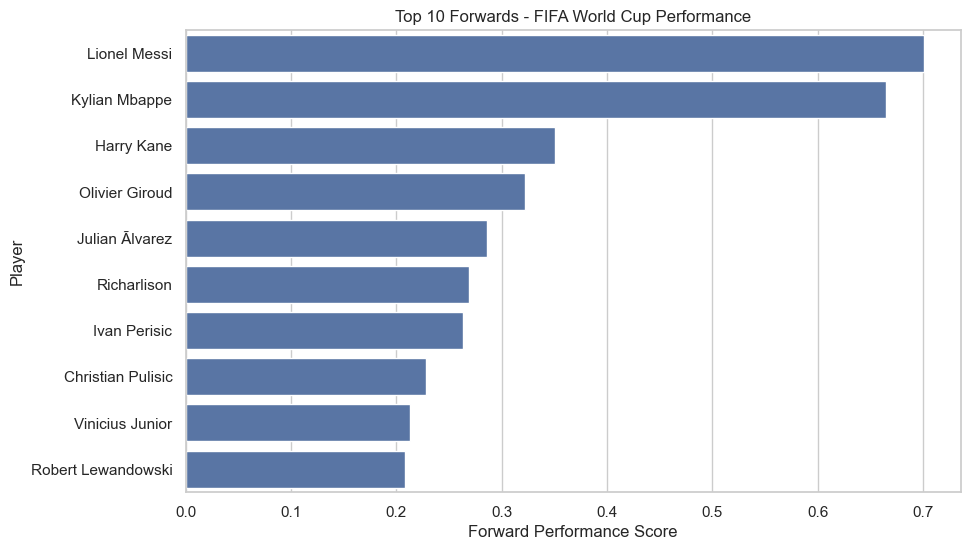

In [70]:
top10_fw = forwards_scaled.sort_values(
    "forward_score", ascending = False
).head(10)

plt.figure()
sns.barplot(
    data=top10_fw, x="forward_score", y="player"
)

plt.title("Top 10 Forwards - FIFA World Cup Performance")
plt.xlabel("Forward Performance Score")
plt.ylabel("Player")

plt.savefig("../visuals/top10_forwards.png", bbox_inches="tight")

plt.show()

#### Top 10 best Midfielders

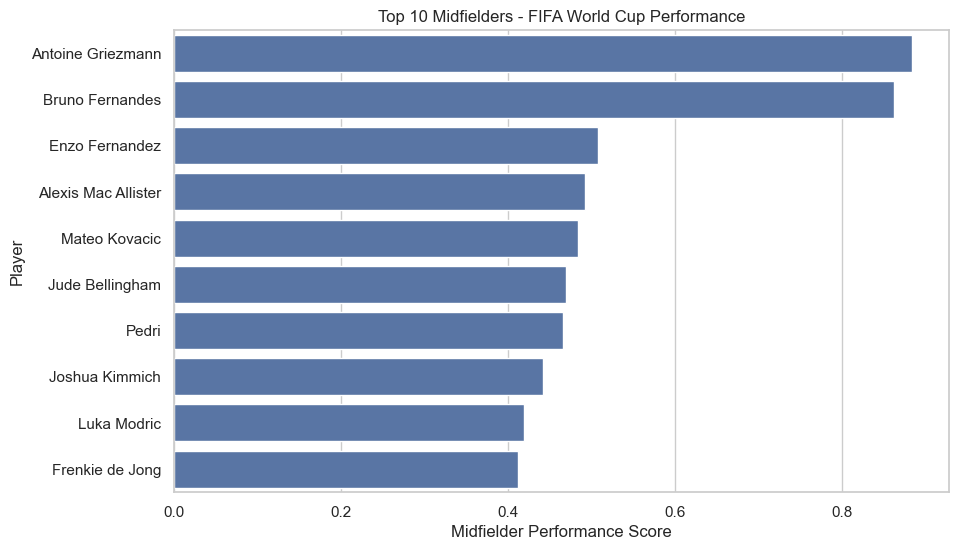

In [71]:
top10_mf = midfielders_scaled.sort_values(
    "midfielder_score", ascending = False
).head(10)

plt.figure()
sns.barplot(
    data=top10_mf, x="midfielder_score", y="player"
)

plt.title("Top 10 Midfielders - FIFA World Cup Performance")
plt.xlabel("Midfielder Performance Score")
plt.ylabel("Player")

plt.savefig("../visuals/top10_midfielders.png", bbox_inches="tight")

plt.show()

#### Top 10 best defenders

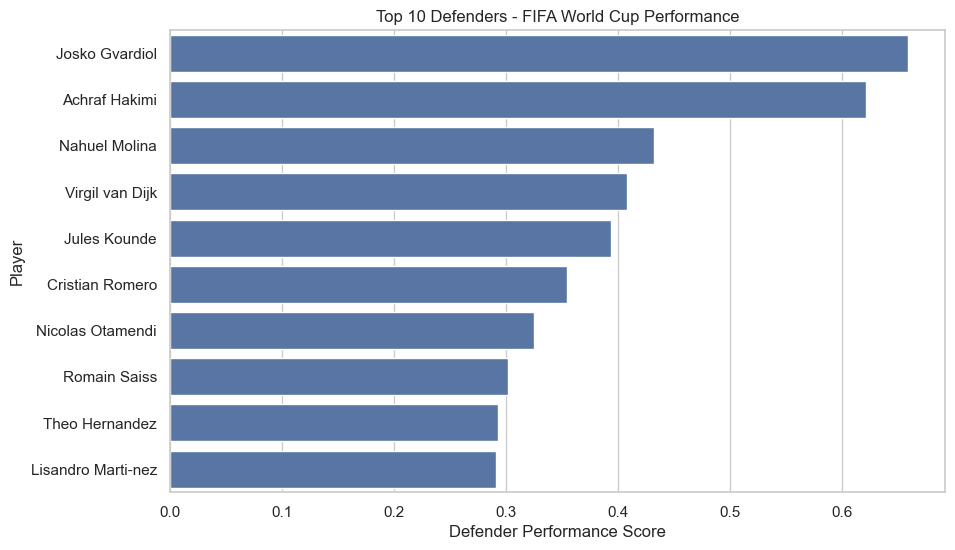

In [72]:
top10_df = defenders_scaled.sort_values(
    "defender_score", ascending = False
).head(10)

plt.figure()
sns.barplot(
    data=top10_df, x="defender_score", y="player"
)

plt.title("Top 10 Defenders - FIFA World Cup Performance")
plt.xlabel("Defender Performance Score")
plt.ylabel("Player")

plt.savefig("../visuals/top10_defenders.png", bbox_inches="tight")

plt.show()

#### Top 10 best Goalkeepers

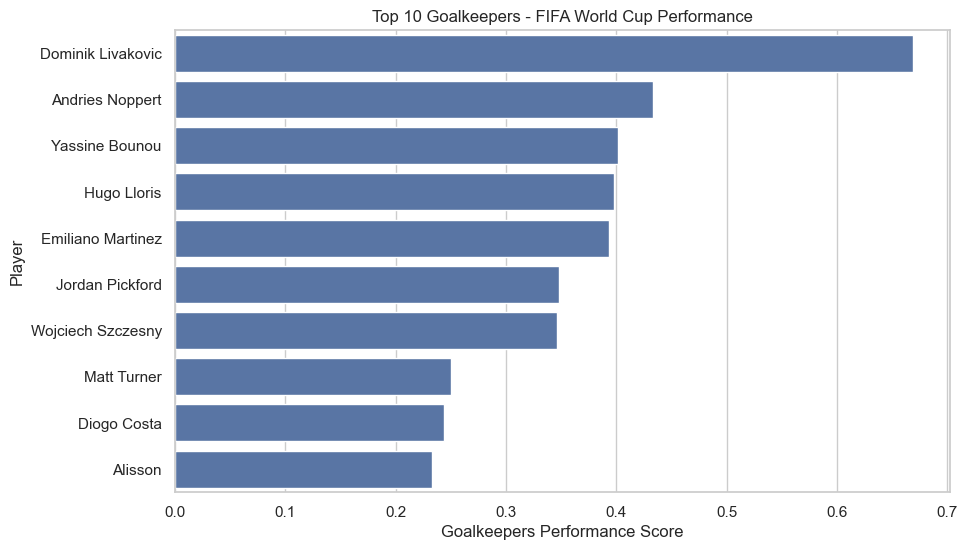

In [73]:
top10_gk= goalkeepers_scaled.sort_values(
    "goalkeeper_score", ascending = False
).head(10)

plt.figure()
sns.barplot(
    data=top10_gk, x="goalkeeper_score", y="player"
)

plt.title("Top 10 Goalkeepers - FIFA World Cup Performance")
plt.xlabel("Goalkeepers Performance Score")
plt.ylabel("Player")

plt.savefig("../visuals/top10_goalkeepers.png", bbox_inches="tight")

plt.show()

#### Goal vs xG Scatter Plot

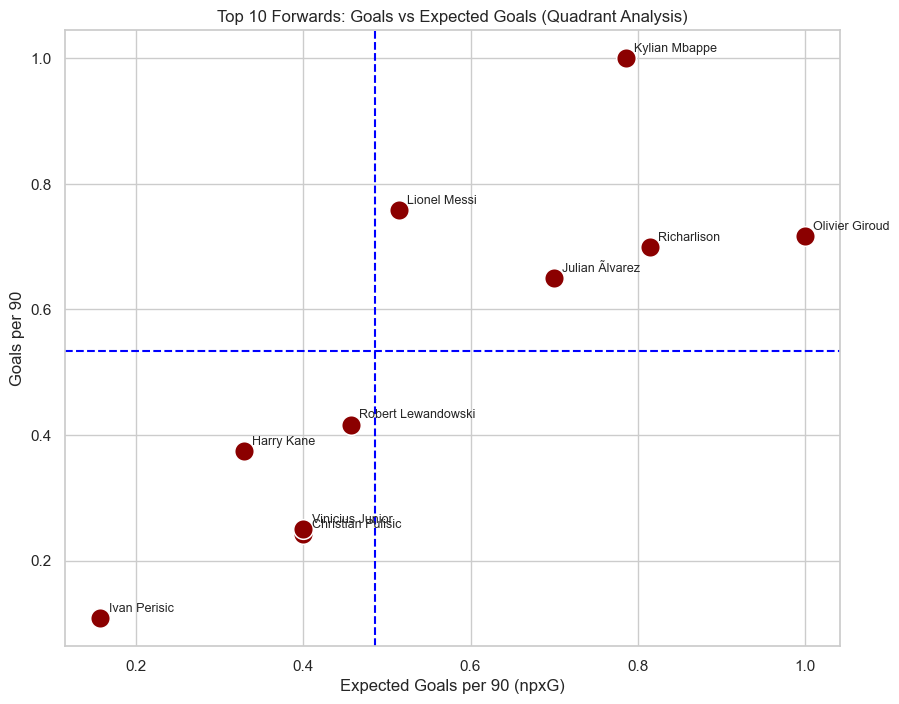

In [74]:
top10_fw = forwards_scaled.sort_values(
    "forward_score", ascending=False
).head(10)

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=top10_fw,
    x="npxg_per90",
    y="goals_per90",
    s=200,
    color="darkred"
)

# Quadrant lines
x_median = top10_fw["npxg_per90"].median()
y_median = top10_fw["goals_per90"].median()

plt.axvline(x=x_median, linestyle="--", color="blue")
plt.axhline(y=y_median, linestyle="--", color="blue")

# Player labels
for i in top10_fw.index:
    plt.text(
        top10_fw.loc[i,"npxg_per90"] + 0.01,
        top10_fw.loc[i,"goals_per90"] + 0.01,
        top10_fw.loc[i,"player"],
        fontsize=9
    )

plt.title("Top 10 Forwards: Goals vs Expected Goals (Quadrant Analysis)")
plt.xlabel("Expected Goals per 90 (npxG)")
plt.ylabel("Goals per 90")

plt.savefig("../visuals/top10_forwards_quadrant.png", dpi=300)

plt.show()

#### Passes vs Chance Creation Visuals

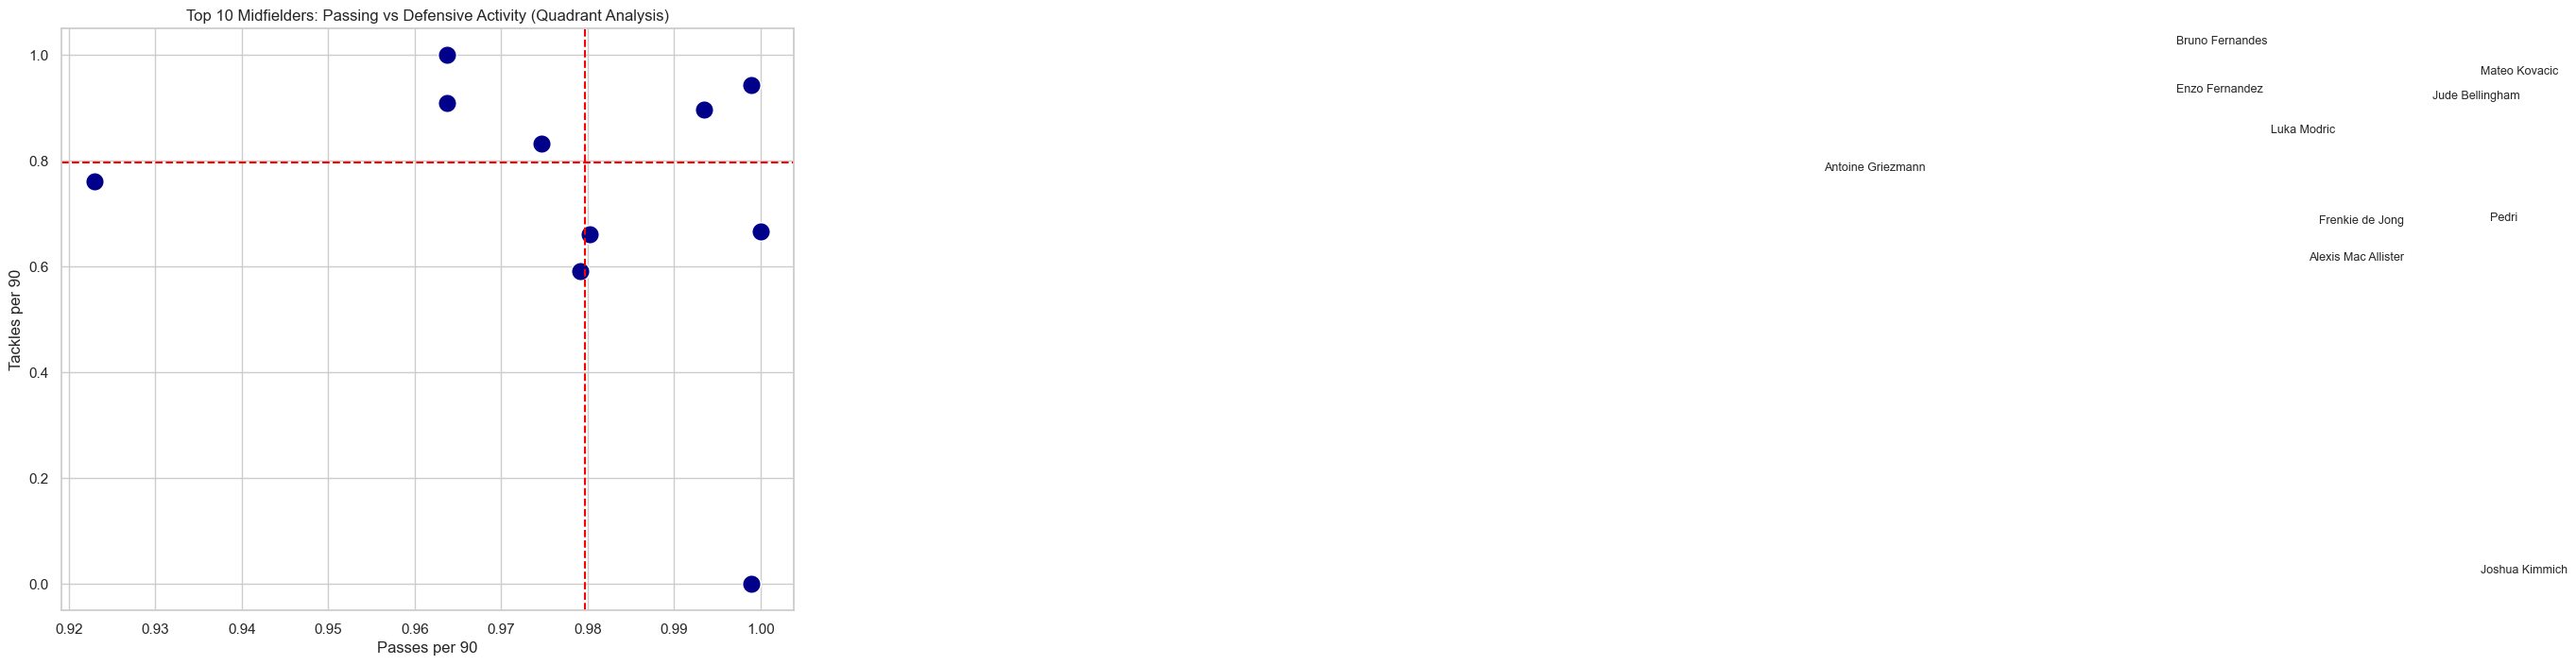

In [124]:
top10_mid = midfielders_scaled.sort_values(
    "midfielder_score", ascending=False
).head(10)

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=top10_mid,
    x="pass_per90",
    y="tackles_per90",
    s=200,
    color="darkblue"
)

# Quadrant lines
x_median = top10_mid["pass_per90"].median()
y_median = top10_mid["tackles_per90"].median()

plt.axvline(x=x_median, linestyle="--", color="red")
plt.axhline(y=y_median, linestyle="--", color="red")

# Labels
for i in top10_mid.index:
    plt.text(
        top10_mid.loc[i,"pass_per90"] + 0.2,
        top10_mid.loc[i,"tackles_per90"] + 0.02,
        top10_mid.loc[i,"player"],
        fontsize=9
    )

plt.title("Top 10 Midfielders: Passing vs Defensive Activity (Quadrant Analysis)")
plt.xlabel("Passes per 90")
plt.ylabel("Tackles per 90")

plt.savefig("../visuals/top10_midfielders_quadrant.png", dpi=300)

plt.show()

#### Defensive Stats Comparison

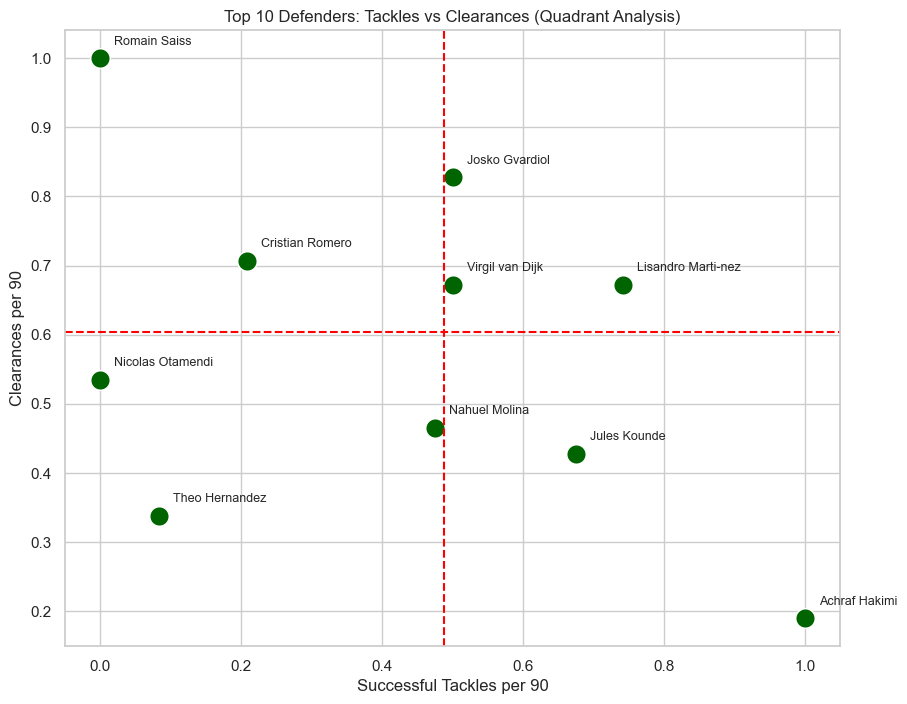

In [76]:
top10_def = defenders_scaled.sort_values(
    "defender_score", ascending=False
).head(10)

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=top10_def,
    x="success_tackles_per90",
    y="clearance_per90",
    s=200,
    color="darkgreen"
)

# Quadrant lines
x_median = top10_def["success_tackles_per90"].median()
y_median = top10_def["clearance_per90"].median()

plt.axvline(x=x_median, linestyle="--", color="red")
plt.axhline(y=y_median, linestyle="--", color="red")

# Player labels
for i in top10_def.index:
    plt.text(
        top10_def.loc[i, "success_tackles_per90"] + 0.02,
        top10_def.loc[i, "clearance_per90"] + 0.02,
        top10_def.loc[i, "player"],
        fontsize=9
    )

plt.title("Top 10 Defenders: Tackles vs Clearances (Quadrant Analysis)")
plt.xlabel("Successful Tackles per 90")
plt.ylabel("Clearances per 90")

plt.savefig("../visuals/top10_defenders_quadrant.png", dpi=300)

plt.show()

#### Goalkeeper Quadrant Visualization (Top 10)

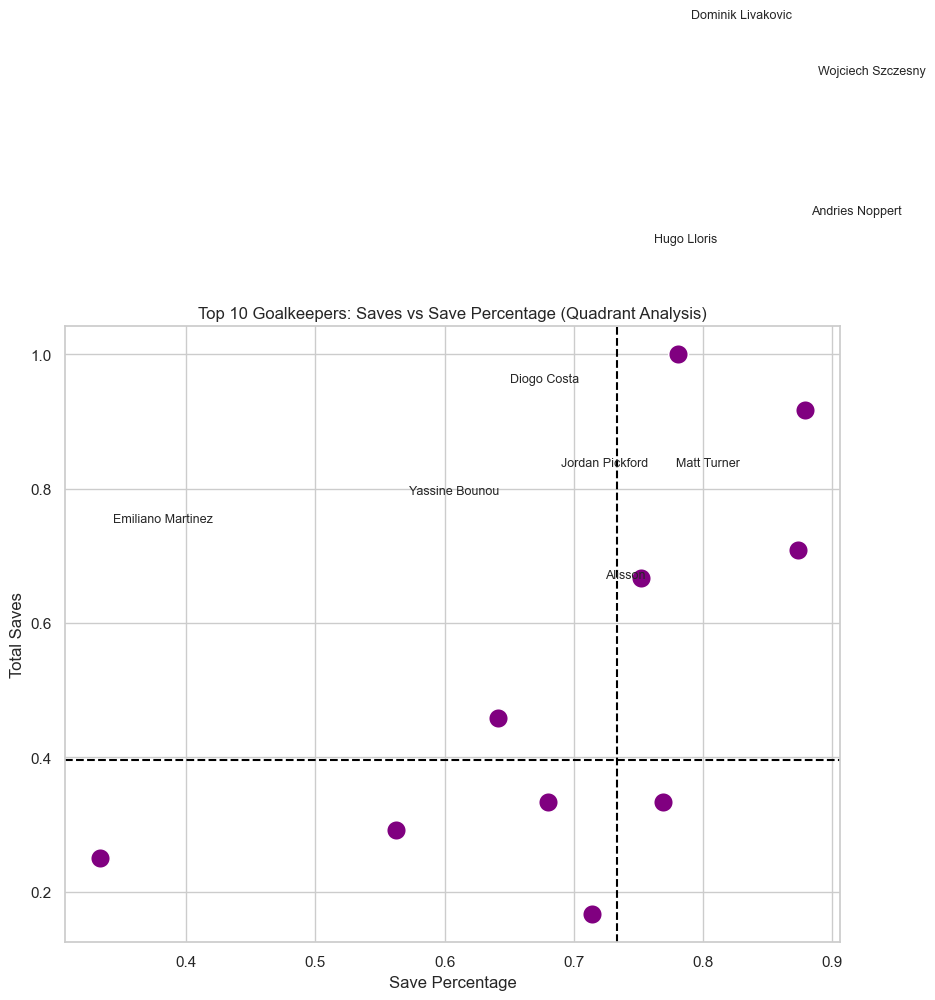

In [77]:
top10_gk = goalkeepers_scaled.sort_values(
    "goalkeeper_score", ascending=False
).head(10)

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=top10_gk,
    x="save_percentage",
    y="saves",
    s=200,
    color="purple"
)

# Quadrant lines
x_median = top10_gk["save_percentage"].median()
y_median = top10_gk["saves"].median()

plt.axvline(x=x_median, linestyle="--", color="black")
plt.axhline(y=y_median, linestyle="--", color="black")

# Player labels
for i in top10_gk.index:
    plt.text(
        top10_gk.loc[i, "save_percentage"] + 0.01,
        top10_gk.loc[i, "saves"] + 0.5,
        top10_gk.loc[i, "player"],
        fontsize=9
    )

plt.title("Top 10 Goalkeepers: Saves vs Save Percentage (Quadrant Analysis)")
plt.xlabel("Save Percentage")
plt.ylabel("Total Saves")

plt.savefig("../visuals/top10_goalkeepers_quadrant.png", dpi=300)

plt.show()

## On field Best XI Visualization


In [84]:
!pip install mplsoccer

  Using cached mplsoccer-1.6.1-py3-none-any.whl.metadata (4.8 kB)
Using cached mplsoccer-1.6.1-py3-none-any.whl (88 kB)


In [85]:
best_XI[["formation_role","player"]]

,formation_role,player
0,GK,Dominik Livakovic
1,LB,Josko Gvardiol
2,CB,Achraf Hakimi
3,RB,Nahuel Molina
4,CB,Virgil van Dijk
5,CM,Antoine Griezmann
6,CM,Bruno Fernandes
7,CM,Enzo Fernandez
8,LW,Lionel Messi
9,RW,Kylian Mbappe


#### Defining Formation Coordinates

In [115]:
positions = {
"GK": (10, 40),

"LB": (30, 10),
"CB1": (30, 30),
"CB2": (30, 50),
"RB": (30, 70),

"CM1": (75, 20),
"CM2": (60, 40),
"CM3": (75, 60),

"LW": (100, 15),
"ST": (105, 40),
"RW": (100, 65)
}

In [121]:
players = {
"GK": best_XI.loc[0, "player"],

"LB": best_XI.loc[3, "player"],
"CB1": best_XI.loc[1, "player"],
"CB2": best_XI.loc[4, "player"],
"RB": best_XI.loc[2, "player"],

"CM1": best_XI.loc[6, "player"],
"CM2": best_XI.loc[7, "player"],
"CM3": best_XI.loc[5, "player"],

"LW": best_XI.loc[9, "player"],
"RW": best_XI.loc[8, "player"],
"ST": best_XI.loc[10, "player"]
}

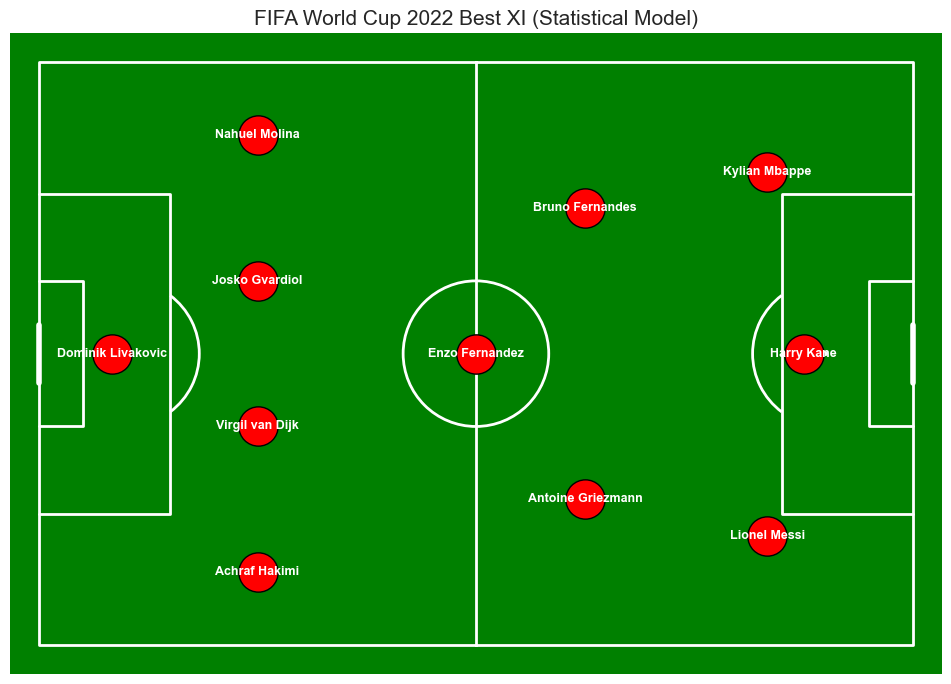

In [123]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# Create pitch
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='green',
    line_color='white'
)

fig, ax = pitch.draw(figsize=(10,7))

# Plot players
for pos, player in players.items():
    
    x, y = positions[pos]
    
    ax.scatter(x, y, s=800, color="red", edgecolors="black")
    
    ax.text(
        x, y, player,
        ha='center',
        va='center',
        color='white',
        fontsize=9,
        weight='bold'
    )

plt.title("FIFA World Cup 2022 Best XI (Statistical Model)", fontsize=15)

fig.savefig("../visuals/bestXI_formation.png", dpi=300, bbox_inches="tight")

plt.show()

## Correlation heatmap

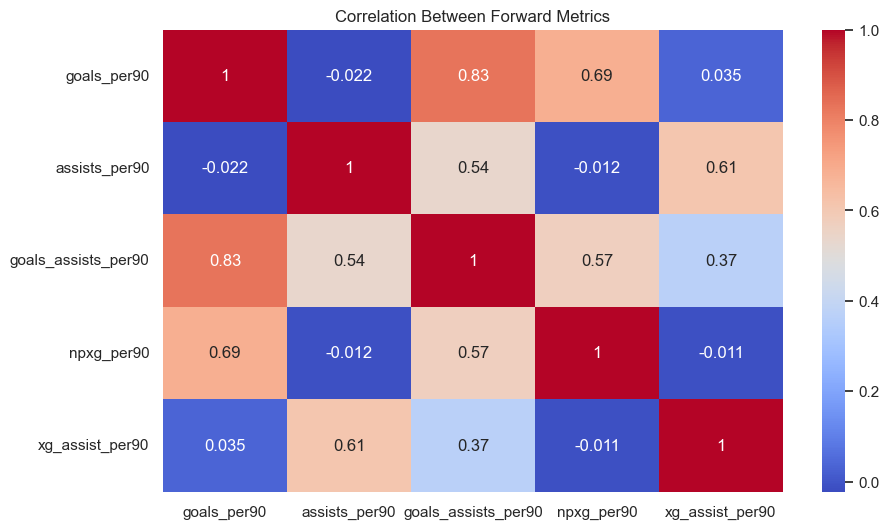

In [126]:
sns.heatmap(
    forwards[forward_metrics].corr(),
    annot =True,
    cmap='coolwarm'
)

plt.title("Correlation Between Forward Metrics")

plt.savefig("../visuals/forward_correlation.png", dpi=300)
plt.show()